## Question 1: Fragment Length Frequency and Rescaling

First part of the problem - Fragment Length Frequency Plot

The import function below reads a gzipped BED file line by line, skips blank/commented lines,  
parses the 2nd and 3rd columns (start and end coordinates),  
computes each fragment’s length (`end - start`),  
and returns both:  
1. A list of all fragment lengths.  
2. A `Counter` object with counts for each unique fragment length.

In [1]:
import numpy as np
import random
import gzip
import matplotlib.pyplot as plt
from collections import Counter

# Function to load the BED file and extract fragment lengths
def import_bed_file(bed_path):
    fragment_lengths = []
    with gzip.open(bed_path, 'rt') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            cols = line.strip().split('\t')
            col1 = int(cols[1])  # Start position of the fragment
            col2 = int(cols[2])  # End position of the fragment
            fragment_lengths.append(col2 - col1)  # Calculate fragment length and store it
    # Return both the list of fragment lengths and their frequency counts
    return fragment_lengths, Counter(fragment_lengths)


In [2]:
fragment_lengths, length_freq = import_bed_file('query.bed.gz')
total_fragments = sum(length_freq.values())
print(f"Loaded {total_fragments:,} fragments from query.bed.gz")

Loaded 13,835,737 fragments from query.bed.gz


Normalization converts raw counts into relative frequencies:

$$
\text{normalized}[l] = \frac{\text{count}[l]}{\sum_{l} \text{count}[l]}
$$

This ensures the frequencies sum to 1, making distributions directly comparable.

In [3]:
def Normalize(length_freq):
    # Normalization helps control noise, avoids overfitting, and keeps data within a comparable range
    sum_tot = sum(length_freq.values())
    return {l: freq / sum_tot for l, freq in length_freq.items()}

normalized_freq = Normalize(length_freq)


#### Plot: Fragment Length Distribution (Query)

We sort fragment lengths in ascending order, extract their normalized frequencies,  
and plot the resulting curve.  
- **X-axis**: fragment length (bp)  
- **Y-axis**: normalized frequency (arbitrary units)  
- The legend shows the total count for reference.


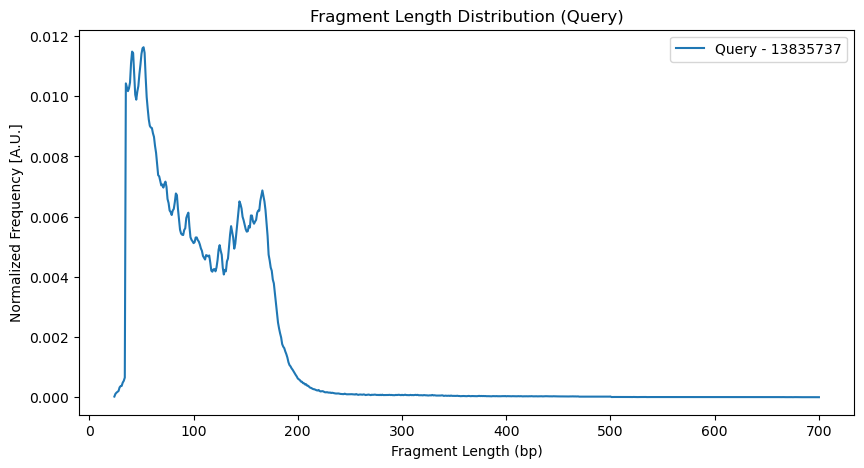

In [4]:
# Sort fragment lengths in increasing order
sorted_lengths = sorted(normalized_freq.keys())

# Arrange the corresponding normalized frequencies in the same order
sorted_freqs = [normalized_freq[l] for l in sorted_lengths]

# Plot the fragment length distribution
plt.figure(figsize=(10, 5))
plt.plot(sorted_lengths, sorted_freqs, label=f'Query - {sum(length_freq.values())}')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution (Query)")
plt.legend()
plt.show()


### Part 2: Rescaling to Reference Distribution

Now we want to *subsample* the query fragments so that its normalized distribution  
*matches* a supplied reference histogram (`reference.hist`).  
This involves:

1. Loading the reference histogram.  
2. Plotting query vs. reference for comparison.  
3. Computing how many fragments of each length we *should* keep.  
4. Randomly sampling from the query fragments accordingly.  
5. Plotting the rescaled distribution alongside the reference.


In [5]:
# Load the reference fragment length distribution
def import_reference_histogram(ref_path):
    # Initialize an empty dictionary to store fragment length and its frequency
    ref_freq = {}
    with open(ref_path) as f:
        for line in f:
            if not line.strip():
                continue
            # Parse fragment length and its frequency
            length, freq = map(float, line.strip().split('\t'))
            ref_freq[int(length)] = freq
    return ref_freq


In [6]:
ref_freq_dict = import_reference_histogram('reference.hist')

#### Plot: Query vs. Reference (Before Rescaling)

Overlay the normalized query distribution and the reference distribution  
to visualize their differences.


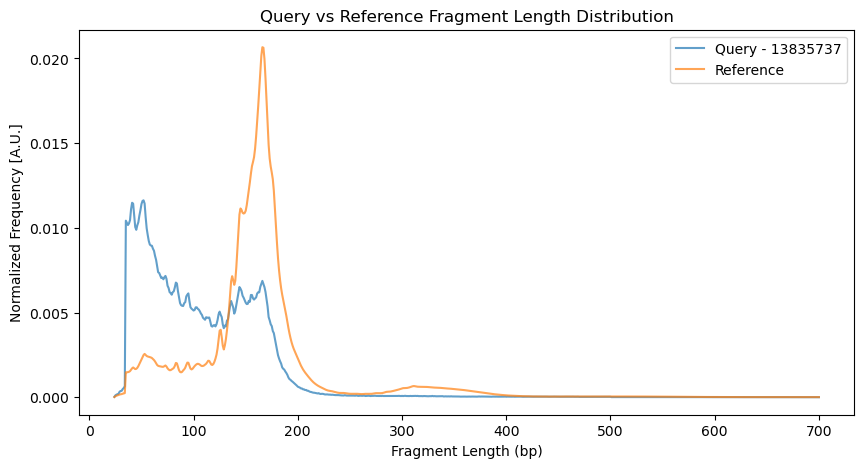

In [7]:
# Prepare the reference histogram for plotting
ref_lengths = sorted(ref_freq_dict.keys())
ref_freqs = [ref_freq_dict[l] for l in ref_lengths]

plt.figure(figsize=(10,5))
plt.plot(sorted_lengths, sorted_freqs, label=f'Query - {sum(length_freq.values())}', alpha=0.7)
plt.plot(ref_lengths, ref_freqs, label='Reference', alpha=0.7)
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Query vs Reference Fragment Length Distribution")
plt.legend()
plt.show()


To match the reference, we:

1. **Group** all query fragments by their length into `fragments_by_length`.  
2. **Set** a target total number of fragments (e.g., 30% of the original).  
3. **For each** length \( \ell \):  
   - Compute `desired_count = round(ref_freq[ℓ] * target_total)`.  
   - **Randomly sample** up to `desired_count` fragments from the pool of query fragments of length \( \ell \).  
4. **Combine** all sampled fragments into `rescaled_fragments`.

In [8]:
# Group the fragments by their length into a dictionary
# The dictionary will have fragment lengths as keys and lists of fragments of that length as values
frag_by_length = {}   
for l in fragment_lengths:
    frag_by_length.setdefault(l, []).append(l)  # Add fragment lengths to the dictionary

# Calculate the total number of fragments
total_fragments = sum(length_freq.values())

# Set the target total number of fragments we want after rescaling (30% of original total)
target_total = int(total_fragments * 0.3)

rescaled_fragments = []

# Loop through each fragment length and its frequency in the reference distribution
for l, ref_freq in ref_freq_dict.items():
    if l in frag_by_length:  

        # Calculate the desired number of fragments based on the reference frequency
        desired_count = int(ref_freq * target_total)

        # Get the current pool of fragments of this length
        current_pool = frag_by_length[l]

        # Randomly sample the required number of fragments from the pool
        sampled = random.sample(current_pool, min(len(current_pool), desired_count))

        # Add the sampled fragments to the list of rescaled fragments
        rescaled_fragments.extend(sampled)


We count how many fragments of each length we ended up with,  
then normalize those counts to get a distribution for the rescaled set.

In [9]:
rescaled_counts = Counter(rescaled_fragments)
total_rescaled = sum(rescaled_counts.values())
rescaled_freq = {i: j / total_rescaled for i, j in rescaled_counts.items()}


#### Plot: Rescaled vs. Reference Distribution

Finally, overlay the rescaled query distribution (as points/lines)  
against the reference distribution (dashed line).  

This shows how well the subsampling matched the target.


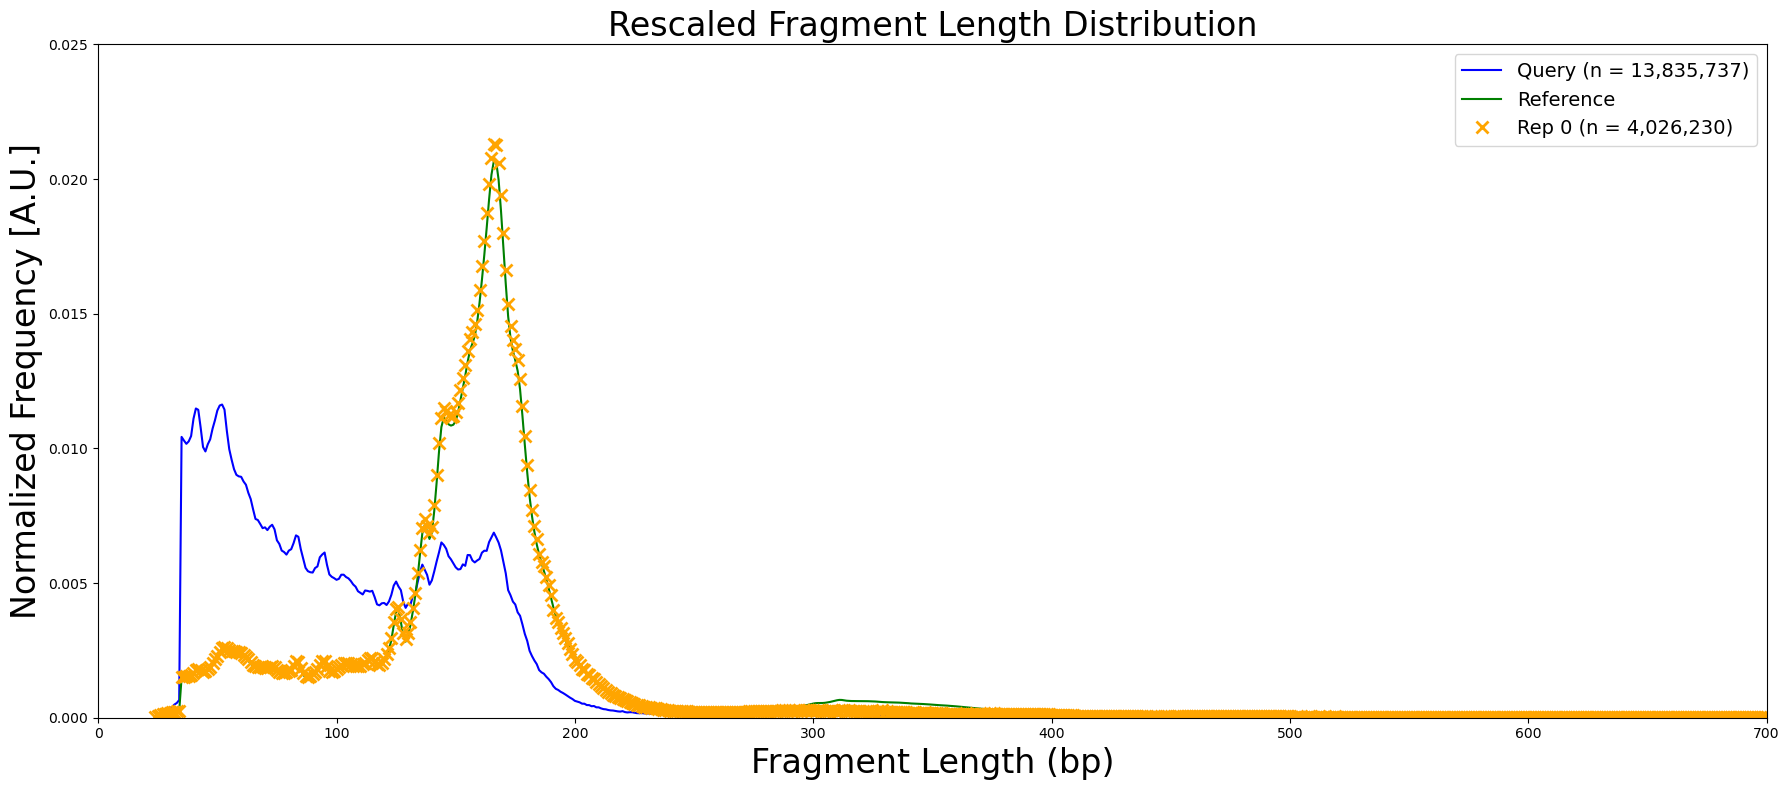

In [10]:
query_x, query_y = sorted_lengths, sorted_freqs
ref_x, ref_y = ref_lengths, ref_freqs
rescaled_x = sorted(rescaled_freq.keys())
rescaled_y = [rescaled_freq[k] for k in rescaled_x]

plt.figure(figsize=(18, 8))
plt.plot(query_x, query_y, label=f'Query (n = {total_fragments:,})', color='blue')
plt.plot(ref_x, ref_y, label='Reference', color='green')
plt.plot(rescaled_x, rescaled_y, 'x', label=f'Rep 0 (n = {total_rescaled:,})', color='orange', markersize=8, markeredgewidth=2)
plt.xlabel("Fragment Length (bp)", fontsize=24)
plt.ylabel("Normalized Frequency [A.U.]", fontsize=24)
plt.title("Rescaled Fragment Length Distribution", fontsize=24)
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("./rescaled_prediction.png")
plt.show()

 Successfully rescaled query distribution to match reference